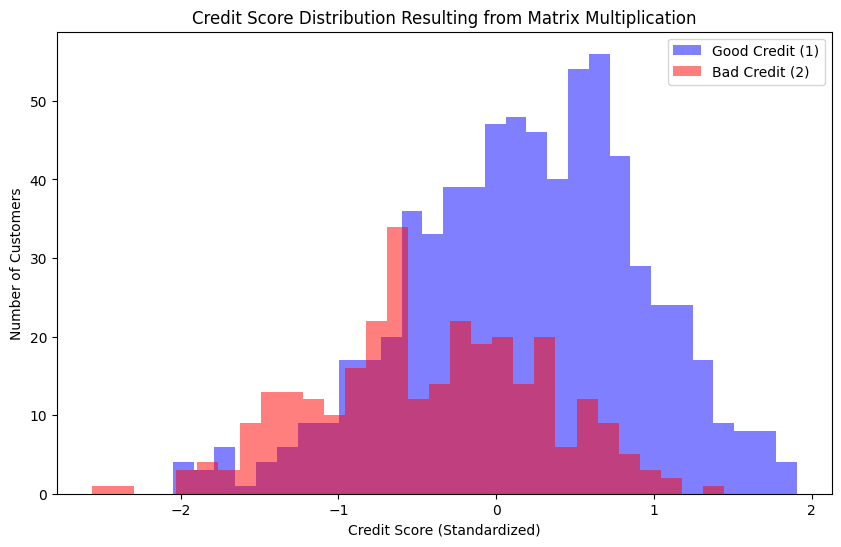

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/content/credit_final_cleaned.csv')

# 1. Pilih Fitur dan Target
X = df.drop('credit_risk', axis=1).values # Matriks Fitur (1000x6)
y = df['credit_risk'].values             # Target

# 2. Normalisasi (Agar semua fitur setara di mata Aljabar)
X_std = (X - X.mean(axis=0)) / X.std(axis=0)

# Menentukan bobot manual untuk 6 fitur:
# [checking, duration, history, purpose, amount, age]
w_expert = np.array([
    [0.4],  # Checking status (Sangat penting)
    [-0.5], # Duration (Makin lama makin berisiko, maka negatif)
    [0.3],  # Credit history
    [0.1],  # Purpose
    [-0.2], # Amount (Makin besar makin berat, maka negatif)
    [0.2]   # Age
])

# 3. MATRIX MULTIPLICATION (The Heart of AI)
# Menghitung skor kredit untuk 1000 orang sekaligus dalam satu kedipan mata
credit_scores = np.dot(X_std, w_expert)

# Simpan skor ke dataframe untuk visualisasi
df['expert_score'] = credit_scores

plt.figure(figsize=(10, 6))

# Plot distribusi untuk Good Credit
plt.hist(df[df['credit_risk'] == 1]['expert_score'], bins=30, alpha=0.5, label='Good Credit (1)', color='blue')

# Plot distribusi untuk Bad Credit
plt.hist(df[df['credit_risk'] == 2]['expert_score'], bins=30, alpha=0.5, label='Bad Credit (2)', color='red')

plt.title('Credit Score Distribution Resulting from Matrix Multiplication')
plt.xlabel('Credit Score (Standardized)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()